In [97]:
# Import required libraries
import torch                                # pytorch
import torch.nn as nn                       # torch의 module, layer
import torch.optim as optim                 # torch의 Optimizer(SGD, Adam)
import torchvision                          # torch의 이미지 데이터 전처리(Resize, Normalize)
import torchvision.transforms as transforms # 변환
from torch.utils.data import DataLoader, random_split, Subset   # 필요한 data ex) MNIST 데이터 있는 부분 / 작은 학습데이터셋을 위한 Subset
import matplotlib.pyplot as plt
import numpy as np


In [98]:
# Hyperparameters
input_size = 28 * 28                        # MNIST images are 28x28 pixels MNIST 입력

hidden_size = 128                           # 은닉층 layer   /  128 => 256
hidden_size_2 = 256                         # 은닉층 layer 256

num_classes = 10                            # MNIST에서 숫자 0 ~ 9 출력 클래스


#num_epochs = 10                             # 에포크 = 10
num_epochs = 30                              # Overfitting 를 확인하기 위한 epoch 증가횟수

batch_size = 64                             # batch_size 한번에 학습하는 데이터 수
learning_rate = 0.001                      # 학습률

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [99]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])               # Normalization 정규화 평균 0.5, 표준편차 0.5 사용
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)   # Train_data 
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)   # test_data


In [100]:
# Split the train set into train and validation(검증)
#train_size = int(0.8 * len(train_dataset))                  # train data를 학습, 검증 나눔
#val_size = len(train_dataset) - train_size
#train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])        # data split


small_train_dataset = Subset(train_dataset, range(2000))
splits = random_split(train_dataset, [len(train_dataset) - 5000, 5000])
val_dataset = splits[1]

In [101]:
# train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)           # DataLoader: 학습에 사용되는 데이터
# val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)              # shuffle: epoch마다 데이터를 섞어 사용
# test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


train_loader = DataLoader(dataset=small_train_dataset, batch_size=batch_size, shuffle=True)         # small dataset를 사용한 DataLoader
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [102]:
# Define the MLP model
class MLP(nn.Module):                       # MLP class 선언 / nn.Module => 신경망 기본 클래스
    def __init__(self, input_size, hidden_size_2, num_classes, dropout_rate):     # 모델 초기화
        super(MLP, self).__init__()                                             # Super 초기화
        self.fc1 = nn.Linear(input_size, hidden_size_2)                           # fc1 첫번째 레이어를 linear layer 선형 레이어 => 은닉층

        self.bn1 = nn.BatchNorm1d(hidden_size_2)                                  # Batch Normalization 배치정규화를 적용
    
        self.relu = nn.ReLU()                                                   # 활성화 함수 => RELU
        #self.sigmoid1 = nn.Sigmoid()                                             # 활성화 함수 => Sigmoid

        self.dropout = nn.Dropout(dropout_rate)                                 # dropout: Overfitting 과적합 해결법 
        self.fc2 = nn.Linear(hidden_size_2, num_classes)                          # fc2 두번째 레이어

    def forward(self, x):                                                       # 모델의 연산 구현
        x = x.view(-1, input_size)
        x = self.fc1(x)
        
        x = self.relu(x)
        #x = self.sigmoid1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [103]:
from torch.utils.tensorboard import SummaryWriter
# TensorBoard setup
writer = SummaryWriter('./runs/logs/')

In [104]:
model = MLP(input_size, hidden_size_2, num_classes, dropout_rate=0.0)
model.to(device)                        # 모델 연산을 device로 이동

# Model summary
from torchsummary import summary
summary(model, (1, 28 * 28))

# Loss and optimizer
criterion = nn.CrossEntropyLoss()           # 손실함수 CrossEntropyLoss 사용
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)        # Optimizer adam 사용 / Weight Decay 적용 weight_decay=1e-5 적용 


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]         200,960
              ReLU-2                  [-1, 256]               0
           Dropout-3                  [-1, 256]               0
            Linear-4                   [-1, 10]           2,570
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.78
Estimated Total Size (MB): 0.79
----------------------------------------------------------------


In [105]:
# Retrieve middle layer weight and bias shapes
fc1_weight_shape = model.fc1.weight.shape                   # fc1의 weight 가중치 
fc1_bias_shape = model.fc1.bias.shape                       # fc1의 bias 바이오스
print(f'FC1 Weight Shape: {fc1_weight_shape}, FC1 Bias Shape: {fc1_bias_shape}')

FC1 Weight Shape: torch.Size([256, 784]), FC1 Bias Shape: torch.Size([256])


In [106]:
# Helper function to visualize images in TensorBoard        # TensorBoard 시각화
def images_to_tensorboard(writer, images, labels, preds=None, step=0, name="Images"):
    img_grid = torchvision.utils.make_grid(images)
    writer.add_image(name, img_grid, global_step=step)
    if preds is not None:
        print(f"Predicted labels: {preds}")
        writer.add_text(f'{name}_Predictions', str(preds.tolist()), step)

In [107]:
# Track the best model
best_val_acc = 0                                            # 정확도
best_model = None                                           # 모델

# Training loop                                             # epoch 학습 루프 시작
for epoch in range(num_epochs):
    model.train()                                           # 모델을 train()
    running_loss = 0.0
    correct = 0                                             # 루프 중 정답 
    total = 0                                               # 루프 총 total

    for i, (images, labels) in enumerate(train_loader):
        # Forward pass 순전파
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))

        # Backward pass and optimization 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()                                    # 옵티마이저 업데이트

        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()

        #Add a few random images to TensorBoard along with their labels (every 100 steps)
        if i % 100 == 0:
            images_to_tensorboard(writer, images, labels, step=epoch * len(train_loader) + i)

    
    train_acc = 100 * correct / total
    val_acc = 0
    val_loss = 0.0
    total = 0
    correct = 0

    # Validation step 검증 단계
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images.to(device))
            loss = criterion(outputs, labels.to(device))
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels.to(device)).sum().item()

    val_acc = 100 * correct / total

    # Log to TensorBoard
    writer.add_scalar('Loss/train', running_loss / len(train_loader), epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Loss/validation', val_loss / len(val_loader), epoch)
    writer.add_scalar('Accuracy/validation', val_acc, epoch)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {running_loss / len(train_loader):.4f}, '
          f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model.state_dict()

# Save the best model
torch.save(best_model, 'best_mlp_model.pth')
writer.close()

Epoch [1/30], Train Loss: 1.3203, Train Acc: 60.40%, Val Acc: 77.18%
Epoch [2/30], Train Loss: 0.5518, Train Acc: 83.60%, Val Acc: 83.44%
Epoch [3/30], Train Loss: 0.4225, Train Acc: 87.75%, Val Acc: 86.80%
Epoch [4/30], Train Loss: 0.3683, Train Acc: 89.65%, Val Acc: 87.20%
Epoch [5/30], Train Loss: 0.3165, Train Acc: 90.85%, Val Acc: 87.38%
Epoch [6/30], Train Loss: 0.2809, Train Acc: 92.40%, Val Acc: 88.28%
Epoch [7/30], Train Loss: 0.2724, Train Acc: 92.75%, Val Acc: 87.46%
Epoch [8/30], Train Loss: 0.2438, Train Acc: 92.60%, Val Acc: 87.94%
Epoch [9/30], Train Loss: 0.2506, Train Acc: 92.50%, Val Acc: 87.26%
Epoch [10/30], Train Loss: 0.2210, Train Acc: 94.00%, Val Acc: 89.00%
Epoch [11/30], Train Loss: 0.1900, Train Acc: 94.35%, Val Acc: 88.86%
Epoch [12/30], Train Loss: 0.1790, Train Acc: 94.70%, Val Acc: 88.98%
Epoch [13/30], Train Loss: 0.1388, Train Acc: 96.40%, Val Acc: 89.20%
Epoch [14/30], Train Loss: 0.1356, Train Acc: 96.80%, Val Acc: 89.56%
Epoch [15/30], Train Loss: 0.

In [108]:
# Test the model
model.load_state_dict(torch.load('best_mlp_model.pth'))
model.eval()                                    # 모델 eval()
model.to('cpu')                                 # cpu 설정
correct = 0
total = 0
all_preds = []                                  # 예측결과
all_labels = []                                 # labels
test_images = []                                # images

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        test_images.extend(images)

test_acc = 100 * correct / total
print(f'Test Accuracy: {test_acc:.2f}%')
# test set 정답률이 97.14 


Test Accuracy: 89.65%


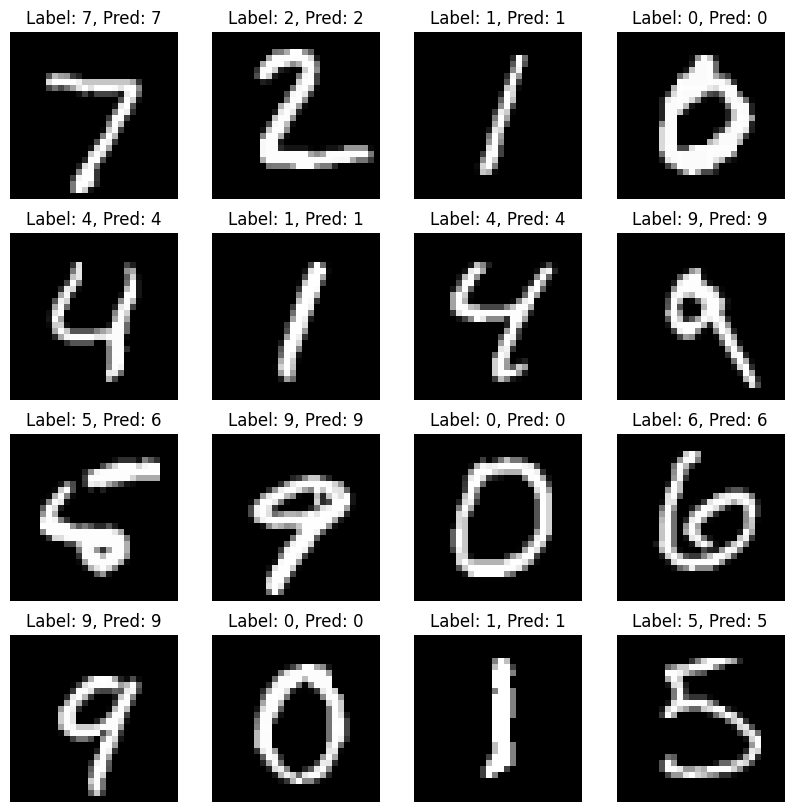

In [109]:
def visualize_predictions(images, labels, preds):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flatten()):
        img = images[i].squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Label: {labels[i]}, Pred: {preds[i]}')
        ax.axis('off')
    plt.show()

test_images = (test_images)[:16]
test_labels = all_labels[:16]
test_preds = all_preds[:16]

visualize_predictions(test_images, test_labels, test_preds)

In [110]:
%pip install scikit-learn
%pip install seaborn
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


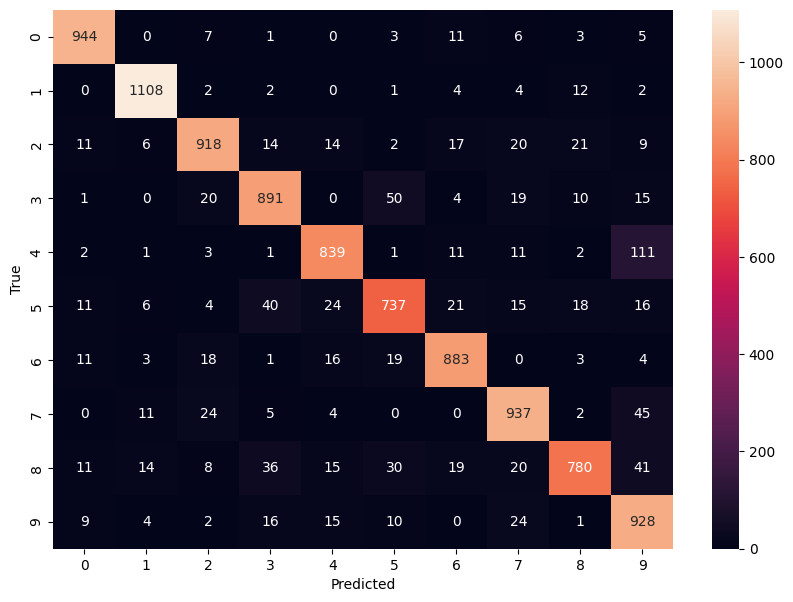

In [111]:
# Confusion matrix visualization
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Close TensorBoard writer


In [112]:
!taskkill /F /PID 8856

����: ���μ��� "8856"��(��) ã�� �� �����ϴ�.


In [113]:
%load_ext tensorboard
%tensorboard --logdir './runs/logs' --port 6007

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 18736), started 17:57:56 ago. (Use '!kill 18736' to kill it.)